# Predicting Student Health Risk — Starter Notebook
### Kaggle Playground Series S6E7

**Goal:** predict `health_condition` (`at-risk`, `unhealthy`, `fit`) for each student in `test.csv`.
**Metric:** Balanced Accuracy (average recall across the 3 classes).

This notebook is a complete, beginner-friendly baseline pipeline:
1. Load data
2. Explore (EDA)
3. Preprocess
4. Train/validate a model
5. Predict on test set
6. Save `submission.csv`

Run this as a Kaggle Notebook attached to the competition (data will be auto-mounted under `/kaggle/input/`), or update the `DATA_DIR` path below if running elsewhere.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "/kaggle/input/competitions/playground-series-s6e7"

## 1. Load the data

In [2]:
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (690088, 15)
Test shape: (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [3]:
test.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


## 2. Explore the data (EDA)

Before doing anything else, always check:
- What columns/types you have
- Missing values
- Class balance of the target (this matters a lot for balanced accuracy!)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [5]:
# Missing values check
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "None found ")

Columns with missing values:
stress_level               82811
sleep_duration             75999
sleep_quality              58331
calorie_expenditure        52853
water_intake               43477
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
step_count                 13916
bmi                        13898
heart_rate                  7833
diet_type                   6901
exercise_duration           6901
dtype: int64


health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64


<Axes: title={'center': 'Target class distribution'}, xlabel='health_condition'>

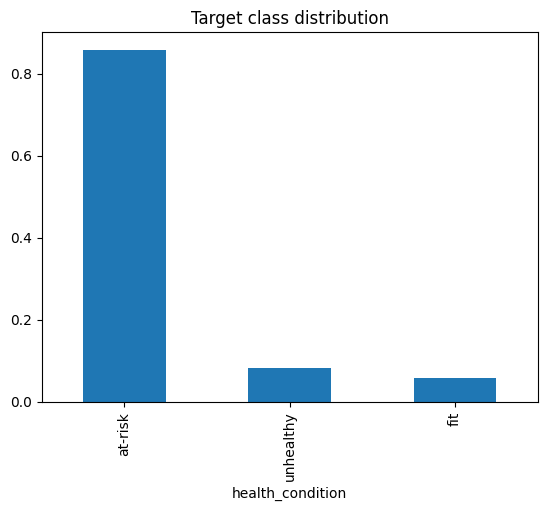

In [6]:
# Target distribution — IMPORTANT for balanced accuracy
target_col = "health_condition"
print(train[target_col].value_counts())
train[target_col].value_counts(normalize=True).plot(kind="bar", title="Target class distribution")

In [7]:
# Quick look at numeric feature distributions
train.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


**Notes for you to fill in as you explore:**
- If one class is much smaller than the others, balanced accuracy will punish a model that ignores it — use `class_weight='balanced'` or stratified sampling.
- Check `train.dtypes` to see which columns are categorical (`object`) vs numeric — they need different preprocessing.


## 3. Preprocessing

In [8]:
# Separate features and target
feature_cols = [c for c in train.columns if c not in [target_col, "id"]]

X = train[feature_cols].copy()
y = train[target_col].copy()
X_test = test[feature_cols].copy()

# Identify categorical vs numeric columns automatically
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
Numeric columns: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']


In [9]:
# Simple missing-value handling
for c in num_cols:
    X[c] = X[c].fillna(X[c].median())
    X_test[c] = X_test[c].fillna(X[c].median())

for c in cat_cols:
    X[c] = X[c].fillna("missing")
    X_test[c] = X_test[c].fillna("missing")

In [10]:
# Encode categorical columns (simple label encoding for a tree-based baseline)
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X[c], X_test[c]], axis=0).astype(str)
    le.fit(combined)
    X[c] = le.transform(X[c].astype(str))
    X_test[c] = le.transform(X_test[c].astype(str))
    encoders[c] = le

# Encode the target labels (at-risk / unhealthy / fit -> 0/1/2)
target_encoder = LabelEncoder()
y_enc = target_encoder.fit_transform(y)
print(dict(zip(target_encoder.classes_, range(len(target_encoder.classes_)))))

{'at-risk': 0, 'fit': 1, 'unhealthy': 2}


## 4. Train and validate a baseline model

We use **StratifiedKFold** cross-validation (keeps class proportions consistent across folds)
and score with **balanced accuracy** — the actual competition metric — not plain accuracy.

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
test_preds_folds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_enc)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_enc[train_idx], y_enc[val_idx]

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",   # helps balanced accuracy directly
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)

    val_pred = model.predict(X_val)
    score = balanced_accuracy_score(y_val, val_pred)
    fold_scores.append(score)
    print(f"Fold {fold+1} balanced accuracy: {score:.5f}")

    # Save this fold's model's test predictions (probabilities) for later averaging
    test_preds_folds.append(model.predict_proba(X_test))

print(f"\nMean CV balanced accuracy: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")

Fold 1 balanced accuracy: 0.86022
Fold 2 balanced accuracy: 0.86527
Fold 3 balanced accuracy: 0.86431
Fold 4 balanced accuracy: 0.85955
Fold 5 balanced accuracy: 0.86124

Mean CV balanced accuracy: 0.86212 (+/- 0.00227)


## 5. Predict on the test set

We average the predicted probabilities across all 5 folds (this is a simple form of ensembling
and usually more stable than a single model).

In [12]:
avg_test_proba = np.mean(test_preds_folds, axis=0)
final_preds_enc = np.argmax(avg_test_proba, axis=1)
final_preds = target_encoder.inverse_transform(final_preds_enc)

print(pd.Series(final_preds).value_counts())

at-risk      261505
unhealthy     19549
fit           14699
Name: count, dtype: int64


## 6. Build and save the submission file

In [13]:
submission = pd.DataFrame({
    "id": test["id"],
    "health_condition": final_preds
})

# Sanity check against sample_submission format
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)

submission.to_csv("submission.csv", index=False)
submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


## Next steps to improve your score

1. **Try a stronger model**: swap `RandomForestClassifier` for `LGBMClassifier` or `CatBoostClassifier` — top public notebooks on this competition are using these and scoring ~0.95 balanced accuracy.
2. **Feature engineering**: look at correlations and interactions between features; one discussion thread suggests the target may be strongly driven by just a few features — check feature importances (`model.feature_importances_`) after training.
3. **Hyperparameter tuning**: use `Optuna` to tune tree depth, learning rate, number of estimators, etc., using the same StratifiedKFold + balanced_accuracy setup above.
4. **Pseudo-labeling**: once you have a strong model, add confidently-predicted test rows back into training data and retrain.
5. **Ensembling**: blend predictions from a few different model types (RF + LightGBM + CatBoost) for a small but reliable boost.

Good luck with your first submission! 🎯